In [33]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


def linear_feature_importances(estimator, **kwargs):
    index = (-estimator.coef_).argsort()
    values = estimator.coef_[:, *index]
    labels = estimator.feature_names_in_[index.squeeze()]
    fig, ax = plt.subplots(**kwargs)
    ax.imshow(values, cmap='Blues')
    ax.set_xticks(range(len(labels)), labels=labels, rotation=90)
    plt.show()


df = pd.read_csv('data/train.csv', index_col='id')
# load original dataset
original = pd.read_csv('data/rainfall.csv').drop(59).reset_index(drop=True)
original.columns = original.columns.str.strip()
original.day = original.index.values + 1
original.rainfall = original.rainfall.apply(lambda value: int(value == 'yes'))
# fill_values = original[df.columns].mean()
df = pd.concat([df[df.columns], original[df.columns]]).reset_index(drop=True)
# load test part
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [34]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
_TEMPERATURES = ['_mintemp', '_temparature', '_maxtemp']


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
    ),
    Select(TEMPERATURES, mode='drop'),

    # categories
    # Calc(month, to='ct_month'),
    Calc(season, to='ct_season'),
    # Bins('cloud', to='ct_cloud', bins=10, as_='code'),
    Bins('humidity', to='ct_humidity', bins=10, as_='code'),
    # Bins('sunshine', to='ct_sunshine', bins=10, as_='code'),

    # trigonometric
    Calc('np.sin(2 * np.pi * day / 365)', to='sin_day'),
    Calc('np.cos(2 * np.pi * day / 365)', to='cos_day'),
    # Calc('np.sin(2 * np.pi * ct_month / 12)', to='sin_month'),
    # Calc('np.cos(2 * np.pi * ct_month / 12)', to='cos_month'),
    Calc('np.sin(2 * np.pi * winddirection / 360)', to='sin_winddirection'),
    Calc('np.cos(2 * np.pi * winddirection / 360)', to='cos_winddirection'),

    # Calc('2 ** (np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365))', to='tg_day'),
    # Calc('2 ** (np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360))', to='tg_winddirection'),
    # Calc('np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365)', to='tg_day'),
    # Calc('np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360)', to='tg_winddirection'),


    # simple features
    # Calc('_maxtemp - _mintemp', 'delta_temp'),
    # Calc('dewpoint / _temparature', 'dewpoint_rate'),
    # Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('windspeed * sin_winddirection * cos_winddirection', to='windspeed_mul_sincos_winddirection'),
    # Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    # Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    # Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),

    # logarithmic
    # Calc('np.log(1 + windspeed * (1 + sin_winddirection * cos_winddirection))', to='log_windspeed_mul_sincos_winddirection'),
    # Calc('np.log(1 + cloud * windspeed)', to='log_cloud_mul_windspeed'),
    # Calc('np.log(1 + humidity * cloud)', to='log_humidity_mul_cloud'),
    # Calc('np.log(1 + humidity * sunshine)', to='log_humidity_mul_sunshine'),
    # Calc('np.log(1 + cloud / (sunshine + 1e-5))', to='log_cloud_div_sunshine'),

    # statistics on categories
    # WithSelected(r'(?!day|ct_(?!month)|mean_).*')(Group('ct_month', 'mean', prefix='mean_ct_month_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!season)|mean_).*')(Group('ct_season', 'mean', prefix='mean_ct_season_', include_target=False)),

    # rainfall statistics
    # WithSelected(['day'])(Group('day', 'median', prefix='median_day_', include_target=True)),
    # WithSelected(['day'])(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # NOTE these following 3 features are logically incorrect: test df has values that are not present in train df
    # WithSelected(['cloud'])(Group('cloud', 'mean', prefix='mean_cloud_', include_target=True)),
    # WithSelected(['humidity'])(Group('humidity', 'mean', prefix='mean_humidity_', include_target=True)),
    # WithSelected(['sunshine'])(Group('sunshine', 'mean', prefix='mean_sunshine_', include_target=True)),

    # WithSelected(['ct_cloud'])(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(['ct_humidity'])(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(['ct_sunshine'])(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),

    # WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'median', prefix='median_day_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'median', prefix='median_ct_cloud_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'median', prefix='median_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_|median_)')(Group('ct_sunshine', 'median', prefix='median_ct_sunshine_', include_target=False)),

    WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'mean', prefix='mean_day_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_|median_)')(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),


    # WithSelected(['ct_sunshine', 'ct_humidity', 'ct_cloud'])(
    # WithSelected(r'(?!day|ct_(?!month|sunshine|humidity|cloud)|mean_|median_)')(
    #     Group(['ct_month', 'ct_sunshine', 'ct_humidity', 'ct_cloud'], 'median', prefix='median_ct_complex_', include_target=False)
    #     # Group(['ct_month', 'ct_sunshine', 'ct_humidity', 'ct_cloud'], 'median', prefix='median_ct_complex_', include_target=True)
    # ),

    # WithSelected(r'(?!day|ct_(?!season|cloud)|mean_|median_)')(
    #     Group(['ct_season', 'ct_cloud'], 'mean', prefix='mean_ct_complex1_', include_target=True)
    # ),
    WithSelected(r'(?!day|ct_(?!season|humidity)|mean_|median_)')(
        Group(['ct_season', 'ct_humidity'], 'mean', prefix='mean_ct_complex2_', include_target=False)
    ),
    # WithSelected(r'(?!day|ct_(?!season|sunshine)|mean_|median_)')(
    #     Group(['ct_season', 'ct_sunshine'], 'mean', prefix='mean_ct_complex3_', include_target=False)
    # ),

    # previous days
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag1_mean_')(Lag(1, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag2_mean_')(Lag(2, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag3_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine', 'cloud'], prefix='last_3days_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine'], prefix='yesterday_')(Lag(1, 'mean')),
    # WithSelected(['sunshine'], prefix='last_3days_mean_')(Lag(3, 'mean')),

    # Calc('yesterday_cloud - cloud', to='delta_cloud'),
    # Calc('yesterday_sunshine - sunshine', to='delta_sunshine'),

    # weather indexes
    Fill('mean'),
    # Calc('np.log(1 + humidity * sunshine / (cloud + 1e-5))', to='wi0'),
    # Calc('(humidity / mean_ct_humidity_humidity) * ', to='wi0'),
    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='wi1'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed + 0.2 * cloud', to='wi2'),
    # Calc('np.log(1 + humidity * cloud * sunshine) * cos_winddirection * sin_winddirection', to='wiA'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed ** (sin_winddirection + cos_winddirection) + 0.2 * cloud', to='wiB'),
    # Calc('weather_index * median_day_rainfall', to='w1_index'),
    # Calc('weather_index * mean_day_rainfall', to='w2_index'),
    # Calc('weather_index * mean_cloud_rainfall', to='w3_index'),
    # Calc('weather_index * mean_humidity_rainfall', to='w4_index'),
    # Calc('weather_index * mean_sunshine_rainfall', to='w5_index'),
    # Calc('weather_index * mean_ct_cloud_rainfall', to='w3_ct_index'),
    # Calc('weather_index * mean_ct_humidity_rainfall', to='w4_ct_index'),
    # Calc('weather_index * mean_ct_sunshine_rainfall', to='w5_ct_index'),

    # drop origin columns
    # Select(['cloud'], mode='drop'),     # NOTE this is the most important feature ?!
    # Select(['cloud', 'dewpoint'], mode='drop'),
    # Select(ORIGIN, mode='drop'),
    Select(_TEMPERATURES, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
    # Fill('mean'),

    # KeepDataframe(pre.QuantileTransformer(random_state=17)),
    # KeepDataframe(make_pipeline(
    #     pre.StandardScaler(),
    #     pre.PowerTransformer(standardize=False)
    # )),
    KeepDataframe(pre.PowerTransformer(standardize=True)),
    # KeepDataframe(pre.StandardScaler()),
    # KeepDataframe(pre.RobustScaler()),

    # KeepDataframe(make_pipeline(
    #     pre.QuantileTransformer(random_state=17),
    #     pre.PowerTransformer(standardize=True)
    #     # pre.MinMaxScaler(),
    # ))
)
sgd_pipe = (
    *base_pipe,
    # WithSelected(r'(?!ct_|day).*$')(KeepDataframe(pre.RobustScaler()))
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X: pd.DataFrame = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)     # type: ignore
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,day,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,ct_season,ct_humidity,...,mean_ct_complex2__mintemp,mean_ct_complex2__maxtemp,mean_ct_complex2__temparature,mean_ct_complex2_sin_day,mean_ct_complex2_cos_day,mean_ct_complex2_sin_winddirection,mean_ct_complex2_cos_winddirection,mean_ct_complex2_cloud_div_humidity,mean_ct_complex2_windspeed_mul_sincos_winddirection,mean_ct_complex2_humidity_mul_sunshine
0,-2.112090,1.110223e-15,-0.395475,0.615036,0.757445,-0.580042,-0.304260,-0.322770,-1.391327,0.842150,...,-1.217177,-1.282130,-1.236017,0.393196,1.357399,1.235910,1.128167,0.732746,1.487624,-1.323239
1,-2.079739,1.693090e-15,-1.094415,1.843960,1.042182,-1.382769,-0.510131,0.193661,-1.391327,1.745630,...,-1.452306,-1.560333,-1.489938,0.478047,1.325081,1.234276,1.251252,0.852033,1.858668,-2.026689
2,-2.050532,2.969847e-15,-1.787224,-0.892654,-1.571264,1.153006,-0.126726,-0.215895,-1.391327,-0.713555,...,-1.457178,-1.417357,-1.451661,0.278043,1.375845,0.797467,1.322743,0.843385,1.314587,-0.279285
3,-2.023458,-8.326673e-17,-0.873050,1.843960,1.450850,-1.382769,-0.304260,1.311287,-1.391327,1.745630,...,-1.452306,-1.560333,-1.489938,0.478047,1.325081,1.234276,1.251252,0.852033,1.858668,-2.026689
4,-1.997973,2.331468e-15,-1.762861,-2.800558,-1.624530,0.312002,-0.756019,0.469625,-1.391327,-2.775153,...,-1.721325,-1.345123,-1.580766,0.352581,1.400299,0.993811,1.498148,-1.887976,1.153926,0.626942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1.541809,2.553513e-15,-1.153194,0.201554,0.945232,-1.382769,-1.063068,-0.181203,-1.391327,0.021991,...,-1.133221,-1.125132,-1.114689,0.229939,1.370543,1.196146,1.093579,1.323994,1.057226,-0.994404
2551,1.549063,3.663736e-15,-1.442013,-0.892654,0.490729,-0.634042,-1.476376,0.567560,-1.391327,-0.713555,...,-1.457178,-1.417357,-1.451661,0.278043,1.375845,0.797467,1.322743,0.843385,1.314587,-0.279285
2552,1.556311,3.441691e-15,-1.381411,-0.892654,-0.064739,0.543100,-0.126726,1.158472,-1.391327,-0.713555,...,-1.457178,-1.417357,-1.451661,0.278043,1.375845,0.797467,1.322743,0.843385,1.314587,-0.279285
2553,1.563554,3.275158e-15,-1.381411,-0.551625,0.577667,-0.528393,-1.476376,0.091726,-1.391327,-0.713555,...,-1.457178,-1.417357,-1.451661,0.278043,1.375845,0.797467,1.322743,0.843385,1.314587,-0.279285


In [303]:
# fig, ax = plt.subplots(figsize=(10, 4.5))
# feature_overview(ax, df.loc[df.rainfall == 0, 'cloud'], FigureType.DENSITY)
# feature_overview(ax, df.loc[df.rainfall == 1, 'cloud'], FigureType.DENSITY)
# plt.show()

__fast check__

Fold: 0; TRAIN ROC AUC=0.89777; TRAIN f1=0.90071 | VALID ROC AUC=0.89492; VALID f1=0.90051
Fold: 1; TRAIN ROC AUC=0.90155; TRAIN f1=0.90157 | VALID ROC AUC=0.87146; VALID f1=0.90033
Fold: 2; TRAIN ROC AUC=0.89623; TRAIN f1=0.90125 | VALID ROC AUC=0.89556; VALID f1=0.89643
Fold: 3; TRAIN ROC AUC=0.90167; TRAIN f1=0.89960 | VALID ROC AUC=0.87439; VALID f1=0.89298
Fold: 4; TRAIN ROC AUC=0.89516; TRAIN f1=0.90127 | VALID ROC AUC=0.90420; VALID f1=0.89384
Fold: 5; TRAIN ROC AUC=0.89532; TRAIN f1=0.89813 | VALID ROC AUC=0.91628; VALID f1=0.90084
Fold: 6; TRAIN ROC AUC=0.89863; TRAIN f1=0.89972 | VALID ROC AUC=0.88842; VALID f1=0.88571
MEAN: TRAIN ROC AUC=0.89805; TRAIN f1=0.90032 | VALID ROC AUC=0.89218; VALID f1=0.89581


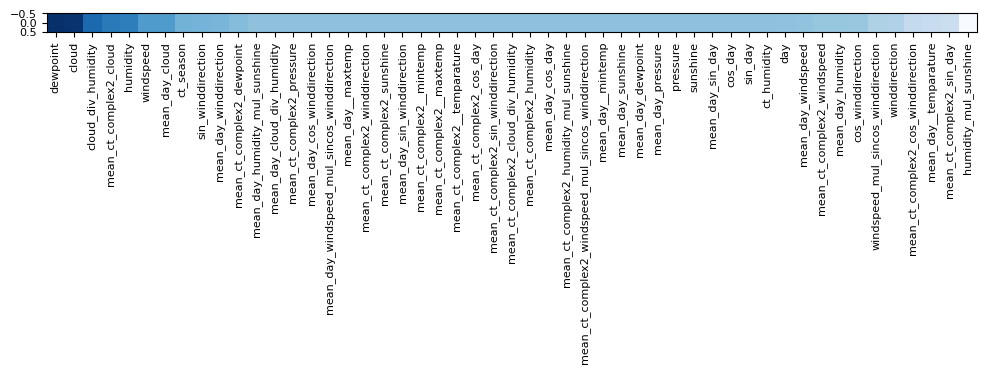

In [35]:
estimator = LogisticRegression(
    # solver='newton-cg',
    # penalty='l2',
    # penalty=None,
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
estimator.fit(SGD_X, y)
linear_feature_importances(estimator, figsize=(12, 4))

In [69]:
# estimator = SGDClassifier(
#     loss='log_loss',
#     learning_rate='adaptive',
#     eta0=0.001,
#     alpha=0.001,
#     penalty='l1',
#     max_iter=15000,
#     n_jobs=-1,
#     # early_stopping=True,
#     # class_weight=CLASS_WEIGHTS.to_dict(),
#     shuffle=False,
#     random_state=13,
# )
# _ = checkup(estimator, SGD_X, y)
# estimator.fit(SGD_X, y)
# linear_feature_importances(estimator, figsize=(12, 4))

__overview new features__

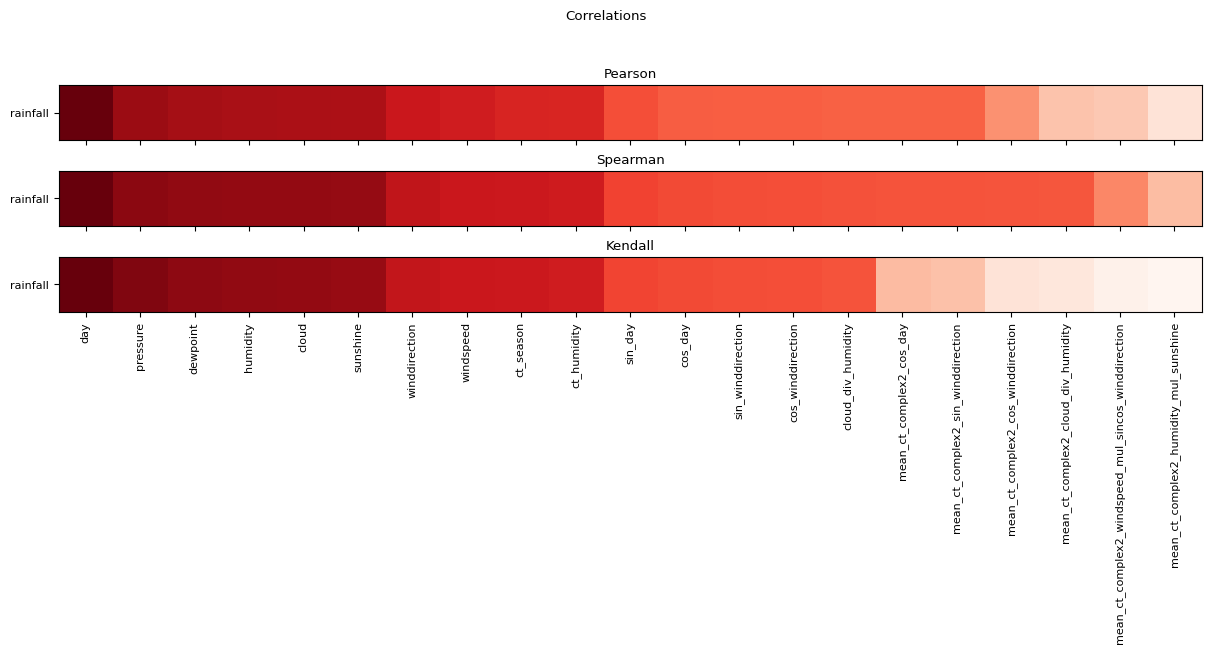

In [36]:
THRESHOLD = 0.075

data = X.copy()
labels = data.columns
data['rainfall'] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 7), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    rainfall_corr = data.corr(method)[['rainfall']].drop('rainfall').sort_values('rainfall', ascending=False)
    values = rainfall_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Reds')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=['rainfall'])
plt.show()

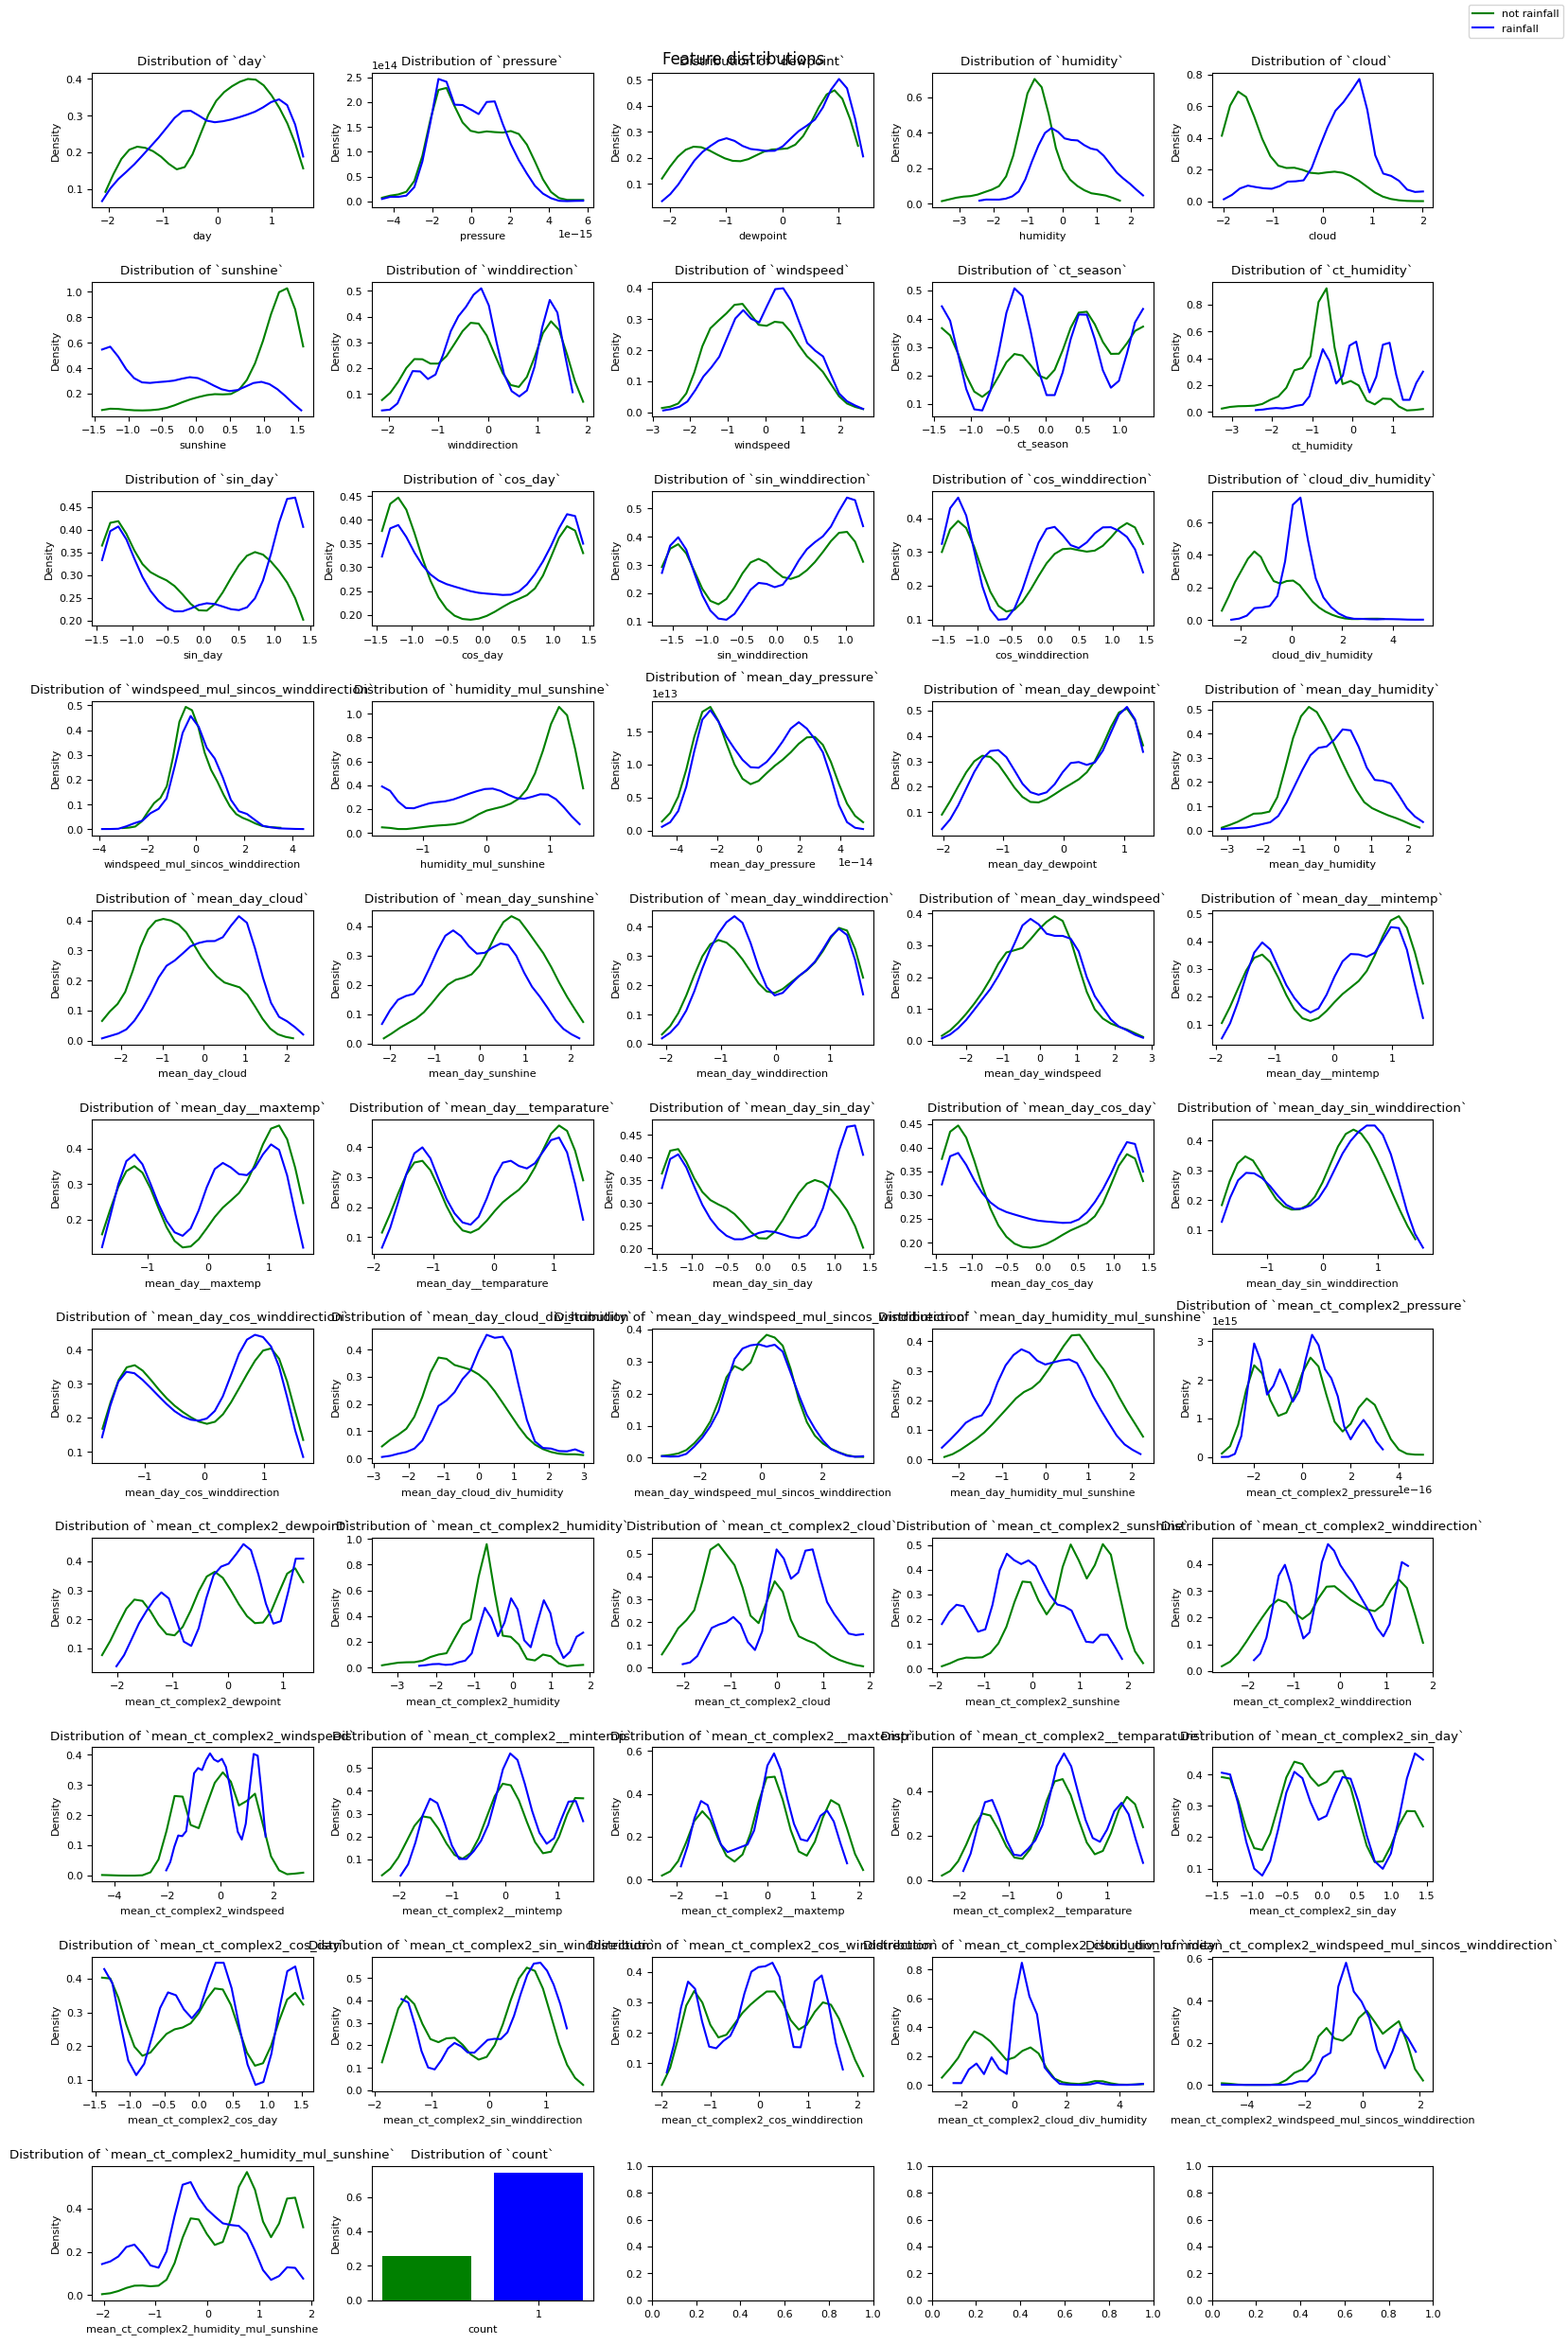

In [37]:
_filter = X.columns
# _filter = X.columns[X.columns.str.match(r'.*_index')]

_X = X[_filter].copy()
_X['rainfall'] = y

COLUMNS = 5
ROWS = max(np.ceil(len(_X.columns) / COLUMNS).astype(int), 2)
SIZE = (COLUMNS * 3, ROWS * 2.25)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(_X.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'rainfall':
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature].value_counts() / _X.shape[0], FigureType.BAR, color='green')
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature].value_counts() / _X.shape[0], FigureType.BAR, color='blue')
        continue
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature], FigureType.DENSITY, bins=25, color='green')
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature], FigureType.DENSITY, bins=25, color='blue')

fig.legend(['not rainfall', 'rainfall'])
plt.show()

__modeling__

In [81]:
# estimator = SGDClassifier(
#     loss='log_loss',
#     learning_rate='adaptive',
#     eta0=0.001,
#     alpha=0.001,
#     penalty='l1',
#     max_iter=15000,
#     n_jobs=-1,
#     # early_stopping=True,
#     # class_weight=CLASS_WEIGHTS.to_dict(),
#     shuffle=False,
#     random_state=13,
# )
# _ = checkup(estimator, SGD_X, y)
# sgd = model = estimator.fit(SGD_X, y)
# linear_feature_importances(model, figsize=(12, 4))

Fold: 0; TRAIN ROC AUC=0.89777; TRAIN f1=0.90071 | VALID ROC AUC=0.89492; VALID f1=0.90051
Fold: 1; TRAIN ROC AUC=0.90155; TRAIN f1=0.90157 | VALID ROC AUC=0.87146; VALID f1=0.90033
Fold: 2; TRAIN ROC AUC=0.89623; TRAIN f1=0.90125 | VALID ROC AUC=0.89556; VALID f1=0.89643
Fold: 3; TRAIN ROC AUC=0.90167; TRAIN f1=0.89960 | VALID ROC AUC=0.87439; VALID f1=0.89298
Fold: 4; TRAIN ROC AUC=0.89516; TRAIN f1=0.90127 | VALID ROC AUC=0.90420; VALID f1=0.89384
Fold: 5; TRAIN ROC AUC=0.89532; TRAIN f1=0.89813 | VALID ROC AUC=0.91628; VALID f1=0.90084
Fold: 6; TRAIN ROC AUC=0.89863; TRAIN f1=0.89972 | VALID ROC AUC=0.88842; VALID f1=0.88571
MEAN: TRAIN ROC AUC=0.89805; TRAIN f1=0.90032 | VALID ROC AUC=0.89218; VALID f1=0.89581


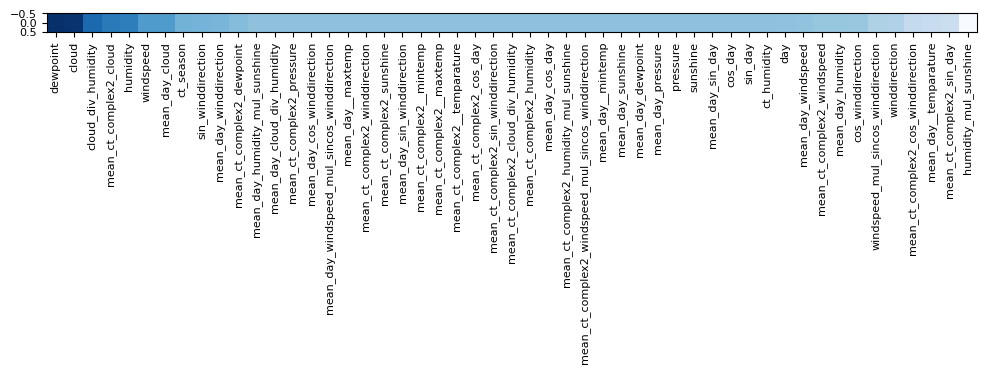

In [38]:
estimator = LogisticRegression(
    # solver='newton-cg',
    # penalty='l2',
    # penalty=None,
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)
linear_feature_importances(model, figsize=(12, 4))

Fold: 0; TRAIN ROC AUC=0.89347; TRAIN f1=0.89977 | VALID ROC AUC=0.89464; VALID f1=0.90301
Fold: 1; TRAIN ROC AUC=0.89753; TRAIN f1=0.90192 | VALID ROC AUC=0.86854; VALID f1=0.90452
Fold: 2; TRAIN ROC AUC=0.89302; TRAIN f1=0.89858 | VALID ROC AUC=0.89176; VALID f1=0.90444
Fold: 3; TRAIN ROC AUC=0.89584; TRAIN f1=0.89867 | VALID ROC AUC=0.87808; VALID f1=0.89562
Fold: 4; TRAIN ROC AUC=0.89219; TRAIN f1=0.90028 | VALID ROC AUC=0.90009; VALID f1=0.89691
Fold: 5; TRAIN ROC AUC=0.89138; TRAIN f1=0.89626 | VALID ROC AUC=0.91172; VALID f1=0.90084
Fold: 6; TRAIN ROC AUC=0.89323; TRAIN f1=0.90256 | VALID ROC AUC=0.89320; VALID f1=0.88172
MEAN: TRAIN ROC AUC=0.89381; TRAIN f1=0.89972 | VALID ROC AUC=0.89115; VALID f1=0.89815


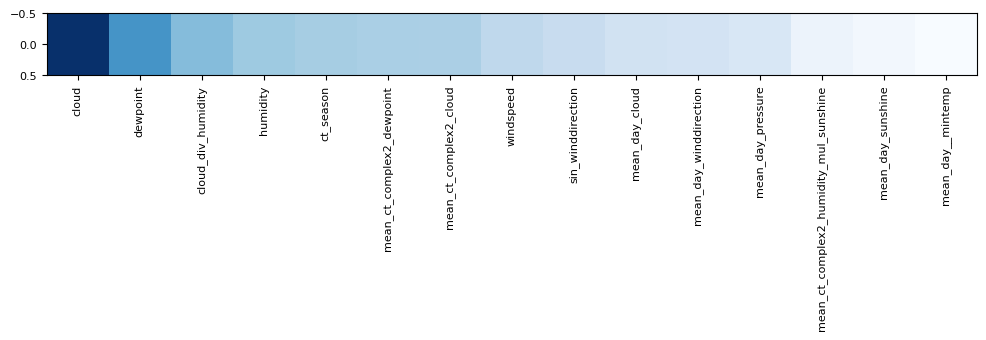

In [41]:
TOP = X.columns[model.coef_.argsort().squeeze()[::-1]][:15]
# TOP
_ = checkup(estimator, SGD_X.loc[:, TOP], y)
lin = deepcopy(estimator).fit(SGD_X.loc[:, TOP], y)
linear_feature_importances(lin, figsize=(12, 4))

__validate on last train year__

In [42]:
estimator = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=131,
)
Xt, Yt = SGD_X[:1825], y[:1825]
Xv, Yv = SGD_X[1825:], y[1825:]
estimator.fit(Xt, Yt)
pt = estimator.predict_proba(Xt).T[1]
pv = estimator.predict_proba(Xv).T[1]

auc_train = roc_auc_score(Yt, pt)
auc_valid = roc_auc_score(Yv, pv)
f1_train = f1_score(Yt, pt > 0.5)
f1_valid = f1_score(Yv, pv > 0.5)

auc_train, auc_valid, f1_train, f1_valid

(0.9006472861938747,
 0.8871653331281737,
 0.9035326086956522,
 0.8955996548748921)

In [43]:
from modeling import EnsembleMeta

ensemble = EnsembleMeta(LogisticRegression, n_estimators=150, random_state=19)(
    solver='liblinear',
    penalty='l1',
    max_iter=1500,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
)
_ = checkup(ensemble, SGD_X, y)
ens = model = ensemble.fit(SGD_X, y, verbose=True)

Fold: 0; TRAIN ROC AUC=0.89777; TRAIN f1=0.90071 | VALID ROC AUC=0.89504; VALID f1=0.90051
Fold: 1; TRAIN ROC AUC=0.90155; TRAIN f1=0.90157 | VALID ROC AUC=0.87146; VALID f1=0.90033
Fold: 2; TRAIN ROC AUC=0.89624; TRAIN f1=0.90125 | VALID ROC AUC=0.89560; VALID f1=0.89643
Fold: 3; TRAIN ROC AUC=0.90168; TRAIN f1=0.89960 | VALID ROC AUC=0.87435; VALID f1=0.89298
Fold: 4; TRAIN ROC AUC=0.89517; TRAIN f1=0.90127 | VALID ROC AUC=0.90424; VALID f1=0.89384
Fold: 5; TRAIN ROC AUC=0.89530; TRAIN f1=0.89839 | VALID ROC AUC=0.91628; VALID f1=0.90084
Fold: 6; TRAIN ROC AUC=0.89860; TRAIN f1=0.89947 | VALID ROC AUC=0.88852; VALID f1=0.88571
MEAN: TRAIN ROC AUC=0.89804; TRAIN f1=0.90032 | VALID ROC AUC=0.89221; VALID f1=0.89581


100%|██████████| 150/150 [00:09<00:00, 16.60it/s]


In [44]:
estimator = KNeighborsClassifier(
    # weights='uniform',
    algorithm='ball_tree',
    n_neighbors=50,
    p=1,
    # leaf_size=64,
    n_jobs=-1,
)
_ = checkup(estimator, SGD_X, y)
knn = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.88477; TRAIN f1=0.90089 | VALID ROC AUC=0.87896; VALID f1=0.88616
Fold: 1; TRAIN ROC AUC=0.88557; TRAIN f1=0.89976 | VALID ROC AUC=0.85047; VALID f1=0.89354
Fold: 2; TRAIN ROC AUC=0.88429; TRAIN f1=0.90041 | VALID ROC AUC=0.88469; VALID f1=0.90357
Fold: 3; TRAIN ROC AUC=0.89004; TRAIN f1=0.90104 | VALID ROC AUC=0.84214; VALID f1=0.88266
Fold: 4; TRAIN ROC AUC=0.88545; TRAIN f1=0.90180 | VALID ROC AUC=0.88360; VALID f1=0.89964
Fold: 5; TRAIN ROC AUC=0.88055; TRAIN f1=0.89635 | VALID ROC AUC=0.88388; VALID f1=0.91711
Fold: 6; TRAIN ROC AUC=0.88333; TRAIN f1=0.90071 | VALID ROC AUC=0.86265; VALID f1=0.88476
MEAN: TRAIN ROC AUC=0.88486; TRAIN f1=0.90014 | VALID ROC AUC=0.86948; VALID f1=0.89535


__wah lol__

Fold: 0; TRAIN ROC AUC=0.90073; TRAIN f1=0.88683 | VALID ROC AUC=0.87844; VALID f1=0.86705
Fold: 1; TRAIN ROC AUC=0.90056; TRAIN f1=0.88732 | VALID ROC AUC=0.87828; VALID f1=0.88192
Fold: 2; TRAIN ROC AUC=0.89940; TRAIN f1=0.89100 | VALID ROC AUC=0.89287; VALID f1=0.90432
Fold: 3; TRAIN ROC AUC=0.90067; TRAIN f1=0.88790 | VALID ROC AUC=0.88113; VALID f1=0.88972
Fold: 4; TRAIN ROC AUC=0.89717; TRAIN f1=0.88825 | VALID ROC AUC=0.90211; VALID f1=0.86770
Fold: 5; TRAIN ROC AUC=0.89751; TRAIN f1=0.88606 | VALID ROC AUC=0.90210; VALID f1=0.90056
Fold: 6; TRAIN ROC AUC=0.90051; TRAIN f1=0.89264 | VALID ROC AUC=0.88356; VALID f1=0.88353
MEAN: TRAIN ROC AUC=0.89951; TRAIN f1=0.88857 | VALID ROC AUC=0.88835; VALID f1=0.88497


100%|██████████| 20/20 [00:58<00:00,  2.94s/it]


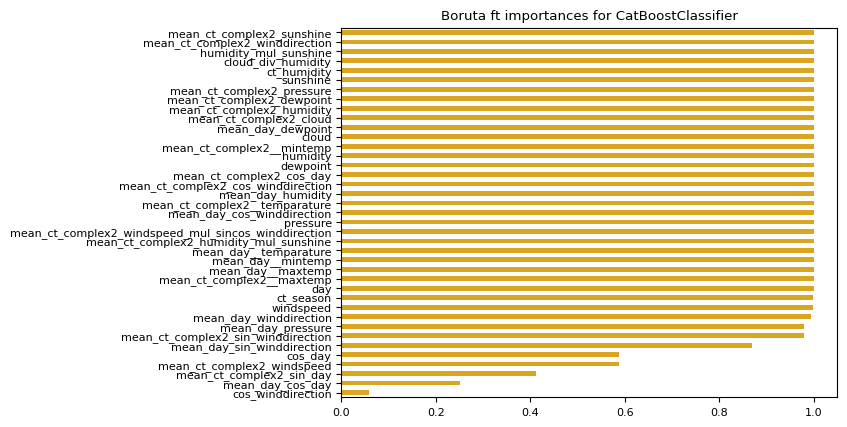

In [45]:
estimator = CatBoostClassifier(
    n_estimators=1500,
    # iterations=1500,
    learning_rate=0.001,
    depth=3,
    class_weights=CLASS_WEIGHTS,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.95)
catboost = model = estimator.fit(X, y)

__submission__

In [5]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

8c2318f4f88b400c8428bb01c480bce6


In [38]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
# T = pipes['sgd'].transform(test.drop(columns='rainfall')).loc[:, TOP]
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

924235e7a16d41da96f604ac06ddbe60


In [ ]:
# logistic regression ensemble
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = ens.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

In [72]:
# KNeighbours
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = knn.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

3f68538198664f9291e4c98f637ce572


In [ ]:
# CatBoost LOL
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b5c1648db89343d191cbd8f500ebbc87


__NN approach__

In [47]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [48]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 51])

In [49]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # linears
            torch.nn.Flatten(1),
            torch.nn.Linear(CHANNELS * ((features - days + 1) // 2), linear_channels // 2),

            # # first conv
            # torch.nn.Conv1d(days, CHANNELS, kernel_size=2 if days > 1 else 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # second conv
            # torch.nn.Conv1d(CHANNELS, days, kernel_size=days - 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # linears
            # torch.nn.Flatten(1),
            # torch.nn.Linear(days * ((((features - days + 1) // 2) - (days > 2)) // 2), linear_channels // 2),

            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels // 2, linear_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(linear_channels // 4, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

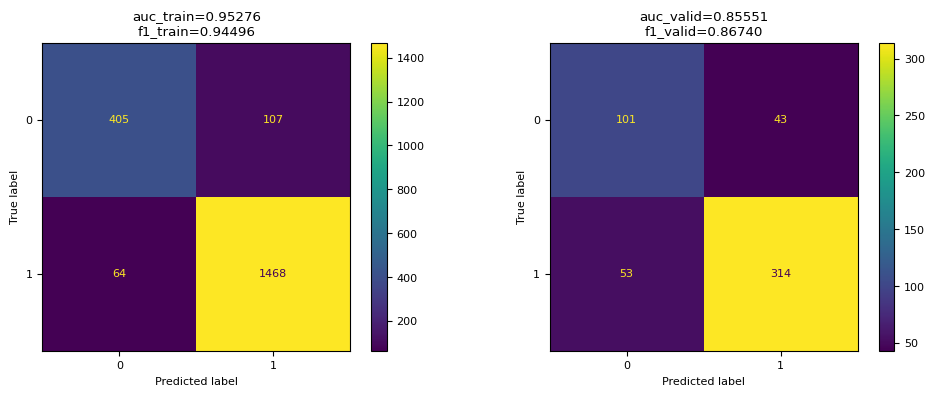

In [51]:
torch.manual_seed(11)
DAYS = 3
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=12,
    linear_channels=96,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=50, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [52]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.94032; TRAIN f1=0.93345 | VALID ROC AUC=0.89010; VALID f1=0.90406
Fold: 1; TRAIN ROC AUC=0.95204; TRAIN f1=0.94167 | VALID ROC AUC=0.84322; VALID f1=0.88246
Fold: 2; TRAIN ROC AUC=0.94789; TRAIN f1=0.92968 | VALID ROC AUC=0.88439; VALID f1=0.89493
Fold: 3; TRAIN ROC AUC=0.95056; TRAIN f1=0.94015 | VALID ROC AUC=0.86806; VALID f1=0.90619
Fold: 4; TRAIN ROC AUC=0.94660; TRAIN f1=0.93827 | VALID ROC AUC=0.86633; VALID f1=0.87850
Fold: 5; TRAIN ROC AUC=0.94050; TRAIN f1=0.92844 | VALID ROC AUC=0.88851; VALID f1=0.91042
Fold: 6; TRAIN ROC AUC=0.94505; TRAIN f1=0.93266 | VALID ROC AUC=0.87899; VALID f1=0.91459
MEAN: TRAIN ROC AUC=0.94614; TRAIN f1=0.93490 | VALID ROC AUC=0.87423; VALID f1=0.89874


__final fit__

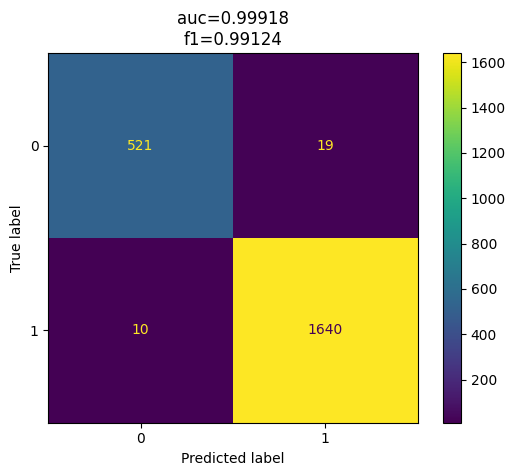

In [12]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=8,
    linear_channels=96,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [13]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = cnn.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

9c500742969546809c17128740a06861


__mix predictions__

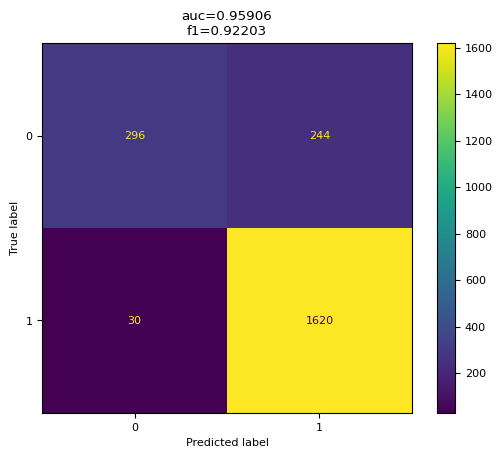

In [307]:
weights = np.array([0.3, 0.4, 0.3]).reshape(3, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    # knn.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0],
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [36]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    knn.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c31d0ac049f346939ce388c0c5eaa524


In [ ]:
#